# W07 训练工程化：向量化环境、回调与日志

> 阶段一（SB3 算法基础）· 第 7 周
> 前置：W05（PPO）、W06（SAC/TD3）

## 学习目标

完成本 notebook 后，你应该能够：

1. 解释 VecEnv 的原理，说明 `n_envs` 如何影响样本吞吐与梯度估计质量；
2. 用 `Monitor` 包装环境、读取日志并绘制学习曲线；
3. 组合 `EvalCallback` + `CheckpointCallback` 实现「定期评估 → 保存最优模型 → 断点存档」的标准训练流水线；
4. 编写自定义回调，在训练过程中插入自己的监控逻辑；
5. 复用 `robot_rl_learn.phase1_sb3` 中的 `train / evaluate / plots` 封装，理解「notebook 做实验、src 做复用」的工程分工；
6. 读懂 TensorBoard 中 SB3 的关键指标，并用它们诊断一次失败的训练。


## 1. 为什么算法之外还要学「训练工程化」

前几周我们关注的是**算法**：损失函数怎么设计、超参数是什么意思。但从本周开始，视角要切换到**工程师**视角。

一个类比：算法是赛车的**引擎**，训练工程化是**仪表盘、行车记录仪和自动进站系统**。没有它们：

- 训练 3 小时，回报曲线长什么样？——不知道（没有日志）；
- 第 2 小时时策略其实很好，第 3 小时崩了——最好的权重丢了（没有评估与最优保存）；
- 机器重启，训练归零（没有检查点）；
- 单机采样太慢，一天只能跑一组实验（没有并行采样）。

RL 训练的特点是**随机性大、失败不报错**：程序正常跑完，策略却是一坨。所以工程化的核心目标是三件事：**可观测（logging）、可恢复（checkpoint）、可复现（seed + 配置管理）**。本周逐一解决。


## 2. 向量化环境：一条产线 vs 多条产线

### 直觉

PPO 每次更新需要一批「rollout」数据（交互轨迹片段）。只用 1 个环境时，采集是**串行**的：走一步、等一步。如果同时开 $N$ 个环境副本，每个副本独立采样，一步就能拿到 $N$ 条转移样本——就像一条产线扩成 $N$ 条产线。

SB3 中 `n_steps` 是**每个环境**的 rollout 长度，因此一次更新实际消耗：

$$\text{batch per update} = n\_steps \times n\_envs$$

例如 `n_steps=256, n_envs=8` 时每次更新用 2048 条样本。更大的 batch 让梯度估计的方差更小、训练更稳，但 `n_envs` 太大也会带来「数据多样性过剩、单条轨迹太短」的问题——这是 W08 调参时要权衡的。

### DummyVecEnv vs SubprocVecEnv

| 实现 | 机制 | 适用 |
|------|------|------|
| `DummyVecEnv` | 同一进程内**顺序**执行各环境 | 环境本身极轻量（CartPole 等），开销最小 |
| `SubprocVecEnv` | 每个环境一个**子进程**，真并行 | 环境单步开销大（物理仿真）时才能赚回进程通信成本 |

`make_vec_env` 默认用 `DummyVecEnv`。对 CartPole 这种一步只要几微秒的环境，子进程的 IPC 开销反而拖慢速度。下面实测一下 `n_envs` 对吞吐的影响：


In [1]:
# 本课程统一在 CPU 上训练：在导入任何深度学习库之前屏蔽 GPU，
# 保证在任何机器上行为一致（部分 GPU 环境下 imitation/torch 存在设备混用问题）
import os

os.environ["CUDA_VISIBLE_DEVICES"] = ""


In [2]:
import time

import numpy as np
from stable_baselines3 import PPO
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.utils import set_random_seed

set_random_seed(42)  # 可复现：固定全局随机种子

# 对比 1 个环境 vs 8 个环境的采样吞吐
for n_envs in [1, 8]:
    env = make_vec_env("CartPole-v1", n_envs=n_envs, seed=0)
    model = PPO("MlpPolicy", env, n_steps=256, batch_size=256, seed=0, verbose=0)
    t0 = time.time()
    model.learn(total_timesteps=8192)
    dt = time.time() - t0
    print(f"n_envs={n_envs:2d}: {dt:5.1f}s -> {8192 / dt:6.0f} steps/s, "
          f"每次更新 batch = 256 x {n_envs} = {256 * n_envs}")
    env.close()


n_envs= 1:  48.7s ->    168 steps/s, 每次更新 batch = 256 x 1 = 256


n_envs= 8: 119.4s ->     69 steps/s, 每次更新 batch = 256 x 8 = 2048


可以看到：在环境极轻量时，`n_envs` 增大带来的吞吐提升有限（数据收集不是瓶颈，策略网络更新才是）；但**每次更新的 batch 变大了**，梯度更稳。到了阶段二/四的物理仿真环境，`SubprocVecEnv` / GPU 并行仿真才会带来数量级的加速。

## 3. Monitor：训练日志的最小单元

SB3 的 `Monitor` 是一个环境 wrapper：每结束一个 episode，就把 `(回报 r, 长度 l, 耗时 t)` 追加写入 `monitor.csv`。它是所有后续分析（学习曲线、实验对比）的数据来源。

**工程要点**：`Monitor` 必须包在环境最外层、且每个并行环境各包一个。`make_vec_env(..., wrapper_class=Monitor)` 会自动给每个子环境都包上。

项目的 `robot_rl_learn.phase1_sb3.plots` 里封装了读日志画曲线的工具，先用短训练演示完整链路：


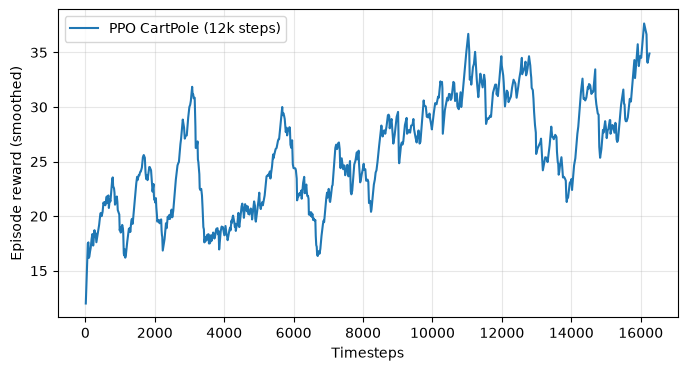

In [3]:
import matplotlib.pyplot as plt
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.monitor import Monitor

from robot_rl_learn.common.paths import make_run_dir
from robot_rl_learn.phase1_sb3.plots import plot_learning_curve

# 一次短训练：把 Monitor 日志写到 runs/w07_monitor_demo/
log_dir = make_run_dir("w07_monitor_demo")
env = make_vec_env("CartPole-v1", n_envs=4, seed=0, wrapper_class=Monitor,
                   monitor_dir=str(log_dir))
model = PPO("MlpPolicy", env, seed=0, verbose=0)
model.learn(total_timesteps=12_000)
env.close()

# 从 Monitor 日志画滑动平均学习曲线
fig, ax = plt.subplots(figsize=(8, 4))
plot_learning_curve({"PPO CartPole (12k steps)": log_dir}, window=20, ax=ax)
plt.show()


> 读图要点：RL 学习曲线**噪声极大**，单个 episode 的回报上蹿下跳是常态，一定要看滑动平均； CartPole 满分 500，曲线顶到 500 附近才算收敛。

## 4. 回调（Callback）：训练循环里的钩子

回调是在 `model.learn()` 的每一步被调用的钩子函数。SB3 内置了三个最常用件：

- **`EvalCallback`**：每 `eval_freq` 步用**独立的评估环境**跑几个 episode，记录评估回报，并自动保存**历史最优模型**（`best_model.zip`）。它解决的是「训练末端的权重往往不是最好的」这个 RL 顽疾。
- **`CheckpointCallback`**：每 `save_freq` 步存档一次完整模型，用于断点恢复和事后分析。
- **`StopTrainingOnRewardThreshold`**：评估回报达标就提前停止，省算力。

> ⚠️ 常见坑：`eval_freq` / `save_freq` 的计数单位是**单个环境的步数**。用 `n_envs=4` 时传 `eval_freq=2000`，实际每 8000 个总步数才评估一次。项目的 `train.py` 里用 `eval_freq // n_envs` 做了换算，自己写代码时别漏。

下面直接调用项目封装好的 `train()`——它内部完成了：向量化环境 + Monitor + EvalCallback（保存最优）+ CheckpointCallback + TensorBoard 日志 + 保存最终模型：


In [4]:
from robot_rl_learn.common.paths import make_run_dir
from robot_rl_learn.phase1_sb3.train import evaluate, train

# 标准流水线：训练 + 定期评估 + 最优模型 + 检查点 + TensorBoard
run_dir = make_run_dir("w07_ppo_cartpole")
model = train(
    "PPO", "CartPole-v1",
    total_timesteps=30_000,   # CPU 上约 30 秒
    n_envs=4,
    seed=0,
    log_dir=run_dir,
    eval_freq=5_000,
)

# 用确定性策略评估最终模型
mean_r, std_r = evaluate(model, "CartPole-v1", n_episodes=10)
print(f"最终模型评估: {mean_r:.1f} ± {std_r:.1f}")


Eval num_timesteps=5000, episode_reward=259.80 +/- 196.34
Episode length: 259.80 +/- 196.34
New best mean reward!


Eval num_timesteps=10000, episode_reward=274.60 +/- 166.06
Episode length: 274.60 +/- 166.06
New best mean reward!


Eval num_timesteps=15000, episode_reward=415.00 +/- 154.97
Episode length: 415.00 +/- 154.97
New best mean reward!


Eval num_timesteps=20000, episode_reward=411.40 +/- 138.27
Episode length: 411.40 +/- 138.27


Eval num_timesteps=25000, episode_reward=400.20 +/- 122.30
Episode length: 400.20 +/- 122.30


Eval num_timesteps=30000, episode_reward=316.40 +/- 95.77
Episode length: 316.40 +/- 95.77


最终模型评估: 421.8 ± 80.6


In [5]:
# 看看一次训练产出了哪些文件（这就是「工程化」的实体）
for p in sorted(run_dir.rglob("*")):
    if p.is_file():
        print(f"{p.relative_to(run_dir)}  ({p.stat().st_size / 1024:.0f} KB)")


best/best_model.zip  (138 KB)
checkpoints/rl_model_10000_steps.zip  (138 KB)
checkpoints/rl_model_15000_steps.zip  (138 KB)
checkpoints/rl_model_20000_steps.zip  (138 KB)
checkpoints/rl_model_25000_steps.zip  (138 KB)
checkpoints/rl_model_30000_steps.zip  (138 KB)
checkpoints/rl_model_5000_steps.zip  (58 KB)
eval/evaluations.npz  (1 KB)
final_model.zip  (138 KB)
tensorboard/PPO_1/events.out.tfevents.1786684950.s131.1327170.0  (3 KB)
tensorboard/PPO_2/events.out.tfevents.1786749963.s131.1642546.0  (3 KB)


/data/wangf/robot_rl_learn/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 35780 (\N{CJK UNIFIED IDEOGRAPH-8BC4}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/data/wangf/robot_rl_learn/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 20272 (\N{CJK UNIFIED IDEOGRAPH-4F30}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/data/wangf/robot_rl_learn/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 26354 (\N{CJK UNIFIED IDEOGRAPH-66F2}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/data/wangf/robot_rl_learn/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 32447 (\N{CJK UNIFIED IDEOGRAPH-7EBF}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/data/wangf/robot_rl_learn/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py

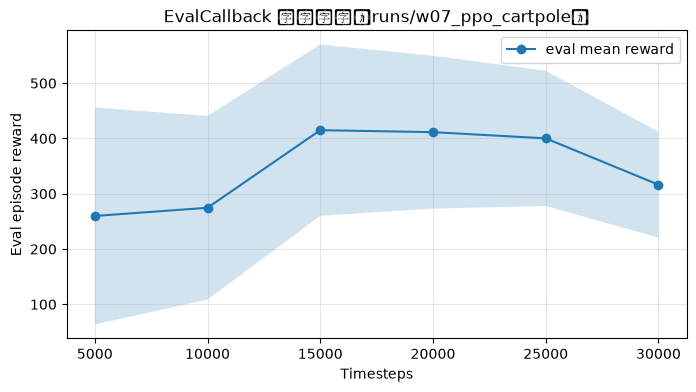

最优模型评估: 328.2 ± 158.4


In [6]:
# 用 EvalCallback 记录的 evaluations.npz 画「评估曲线」——比训练曲线更可信
import matplotlib.pyplot as plt
from stable_baselines3 import PPO

eval_data = np.load(run_dir / "eval" / "evaluations.npz")
timesteps = eval_data["timesteps"]           # 每次评估时的总步数
results = eval_data["results"]               # shape: (n_evals, n_eval_episodes)

mean_r = results.mean(axis=1)
std_r = results.std(axis=1)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(timesteps, mean_r, marker="o", label="eval mean reward")
ax.fill_between(timesteps, mean_r - std_r, mean_r + std_r, alpha=0.2)
ax.set_xlabel("Timesteps")
ax.set_ylabel("Eval episode reward")
ax.set_title("EvalCallback 评估曲线（runs/w07_ppo_cartpole）")
ax.legend()
ax.grid(alpha=0.3)
plt.show()

# 顺便加载「历史最优模型」评估一下——它往往比最终模型更稳
best = PPO.load(run_dir / "best" / "best_model")
mean_b, std_b = evaluate(best, "CartPole-v1", n_episodes=10)
print(f"最优模型评估: {mean_b:.1f} ± {std_b:.1f}")


## 5. 自定义回调

内置回调不够用时就自己写。框架很简单：继承 `BaseCallback`，重写 `_on_step()`（每步调用）或 `_on_rollout_end()` 等钩子，返回 `False` 可中断训练。

下面这个回调统计「最近 100 个 episode 的平均回报」，并在连续达标时提前停止训练——相当于手写一个简化版 `StopTrainingOnRewardThreshold`：


In [7]:
from collections import deque

from stable_baselines3 import PPO
from stable_baselines3.common.callbacks import BaseCallback
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.monitor import Monitor


class EarlyStopOnTrainReward(BaseCallback):
    """训练环境最近 window 个 episode 平均回报 >= threshold 时提前停止。"""

    def __init__(self, threshold: float, window: int = 100, verbose: int = 0):
        super().__init__(verbose)
        self.threshold = threshold
        self.rewards = deque(maxlen=window)

    def _on_step(self) -> bool:
        # VecEnv 的 infos 里，Monitor 会在 episode 结束时塞入 "episode" 字典
        for info in self.locals["infos"]:
            if "episode" in info:
                self.rewards.append(info["episode"]["r"])
        if len(self.rewards) == self.rewards.maxlen:
            mean_r = np.mean(self.rewards)
            if mean_r >= self.threshold:
                print(f"\n[EarlyStop] 最近 {len(self.rewards)} 个 episode "
                      f"平均回报 {mean_r:.1f} >= {self.threshold}，停止训练")
                return False  # 返回 False -> learn() 停止
        return True


env = make_vec_env("CartPole-v1", n_envs=4, seed=1, wrapper_class=Monitor)
model = PPO("MlpPolicy", env, seed=1, verbose=0)
cb = EarlyStopOnTrainReward(threshold=475.0)
model.learn(total_timesteps=100_000, callback=cb)  # 上限 100k，达标会提前停
print(f"实际训练步数: {model.num_timesteps}")
env.close()



[EarlyStop] 最近 100 个 episode 平均回报 475.5 >= 475.0，停止训练
实际训练步数: 96068


## 6. TensorBoard：RL 训练的仪表盘

`train()` 已经把所有标量写进了 `runs/w07_ppo_cartpole/tensorboard/`。在项目根目录启动：

```bash
uv run tensorboard --logdir runs/
```

然后在浏览器中重点看这几组指标（「一次失败的训练长什么样」是面试和调试的高频题）：

| 指标 | 含义 | 危险信号 |
|------|------|----------|
| `rollout/ep_rew_mean` | 训练环境 episode 平均回报 | 长期不涨、或冲高后崩盘 |
| `train/approx_kl` | 新旧策略的近似 KL 散度 | 持续 > 0.05：学习率/clip 太激进 |
| `train/clip_fraction` | 被 PPO clip 截断的样本比例 | 长期 > 0.3：策略更新步长过大 |
| `train/entropy_loss` | 策略熵（负值） | 绝对值过早趋零：探索坍塌，容易卡在局部最优 |
| `train/value_loss` | 价值网络损失 | 持续不降或爆炸：critic 没学好，检查 reward 尺度 |

**诊断套路**：回报不涨 → 先看 `approx_kl` 和 `clip_fraction` 判断是「步子太大」还是「根本没学到」（熵早早归零、KL 恒为 0）→ 再看 `value_loss` 排除 critic 问题。练习 3 会让你亲手制造并诊断一次失败训练。


## ✏️ 练习

> 每题都要亲手写出代码并运行，参考答案仅用于对答案。

### 练习 1（★，约 15 分钟）：`n_envs` 对吞吐与收敛的影响
用第 2 节的代码框架，把 `n_envs` 取 `{1, 4, 16}` 各跑一次（`total_timesteps=8192`，其余参数不变），记录 steps/s；再用同一套超参把三组各训练 30k 步并评估 10 个 episode。
**可交付物**：一张 3 行的表格（n_envs / steps-s / 30k 步后的评估回报均值）+ 一句话结论：本机上吞吐主要受什么限制？

### 练习 2（★★，约 20 分钟）：评估达标早停
组合使用 `EvalCallback` 与 `StopTrainingOnRewardThreshold`，实现「**评估回报**达到 490 就停止训练并保存最优模型」（注意：是评估环境的回报，不是训练环境的滑动平均）。
**可交付物**：可运行代码 + 打印出的实际训练步数（应明显小于 `total_timesteps` 上限）。

### 练习 3（★★，约 25 分钟）：制造并诊断一次失败训练
把 PPO 的 `learning_rate` 调大到 `1e-2`（或自行选择破坏性超参），训练 20k 步，用 `evaluations.npz` 或 TensorBoard 给出**至少两条**量化证据证明训练失败/不稳定（提示：`approx_kl`、`clip_fraction`、评估回报方差）。
**可交付物**：一张图或一段打印输出 + 3~5 句诊断分析。

### 练习 4（★★★，约 30 分钟）：断点恢复训练
从 `runs/w07_ppo_cartpole/checkpoints/` 中加载一个中间检查点（不是 final_model），在同一环境上**继续**训练 10k 步（提示：`model.learn(..., reset_num_timesteps=False)` 保持步数计数连续），并评估继续训练前后的回报。
**可交付物**：代码 + 继续训练前后的评估回报对比 + 一句话说明 `reset_num_timesteps=False` 影响了哪些记录。


## 参考答案

### 练习 1

<details>
<summary>参考答案</summary>

```python
import time
from stable_baselines3 import PPO
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.evaluation import evaluate_policy

rows = []
for n_envs in [1, 4, 16]:
    env = make_vec_env("CartPole-v1", n_envs=n_envs, seed=0)
    model = PPO("MlpPolicy", env, n_steps=256, batch_size=256, seed=0, verbose=0)
    t0 = time.time()
    model.learn(total_timesteps=8192)
    sps = 8192 / (time.time() - t0)
    # 重新训练 30k 评估（也可直接复用上面模型继续 learn）
    model.learn(total_timesteps=30_000 - 8192)
    mean_r, _ = evaluate_policy(model, env, n_eval_episodes=10, deterministic=True)
    rows.append((n_envs, round(sps), round(mean_r, 1)))
    env.close()

print(f"{'n_envs':>6} {'steps/s':>8} {'eval_reward':>12}")
for r in rows:
    print(f"{r[0]:>6} {r[1]:>8} {r[2]:>12}")
```

典型结论：CartPole 上 steps/s 随 `n_envs` 增长有限（瓶颈在策略网络更新而非采样），但 batch 增大让 30k 步后的回报更稳。结论允许因机器而异，关键是有数据支撑。

</details>

### 练习 2

<details>
<summary>参考答案</summary>

```python
import gymnasium as gym
from stable_baselines3 import PPO
from stable_baselines3.common.callbacks import EvalCallback, StopTrainingOnRewardThreshold
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.monitor import Monitor
from robot_rl_learn.common.paths import make_run_dir

run_dir = make_run_dir("w07_ex2_early_stop")

# 关键：阈值回调挂在 EvalCallback 的 callback_on_new_best 上，
# 判断依据是评估环境的 best_mean_reward，而不是训练环境的滑动平均
stop_cb = StopTrainingOnRewardThreshold(reward_threshold=490.0, verbose=1)
eval_cb = EvalCallback(
    Monitor(gym.make("CartPole-v1")),
    callback_on_new_best=stop_cb,
    eval_freq=2_000,
    best_model_save_path=str(run_dir / "best"),
    verbose=1,
)

env = make_vec_env("CartPole-v1", n_envs=4, seed=0, wrapper_class=Monitor)
model = PPO("MlpPolicy", env, seed=0, verbose=0)
model.learn(total_timesteps=200_000, callback=eval_cb)
print(f"实际训练步数: {model.num_timesteps}")  # 远小于 200k 即成功
```

</details>

### 练习 3

<details>
<summary>参考答案</summary>

```python
import numpy as np
from stable_baselines3 import PPO
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.monitor import Monitor
from robot_rl_learn.common.paths import make_run_dir

run_dir = make_run_dir("w07_ex3_bad_run")
env = make_vec_env("CartPole-v1", n_envs=4, seed=0, wrapper_class=Monitor)
model = PPO("MlpPolicy", env, learning_rate=1e-2, seed=0, verbose=0,
            tensorboard_log=str(run_dir / "tb"))
model.learn(total_timesteps=20_000)
env.close()
```

诊断证据（可从 TensorBoard 或 logger 读取）：

1. `rollout/ep_rew_mean` 剧烈震荡，评估回报均值与方差都很大（策略不稳定）；
2. `train/approx_kl` 多次冲到 0.1 以上（正常应 < 0.05），说明每次更新新旧策略差异过大；
3. `train/clip_fraction` 长期 > 0.3，大量样本被 clip，实际有效更新很少。

结论模板：「学习率过大 → 策略更新步长过大 → KL 飙升 + clip 比例过高 → 回报震荡不收敛」。
</details>

### 练习 4

<details>
<summary>参考答案</summary>

```python
from pathlib import Path
from stable_baselines3 import PPO
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.monitor import Monitor
from robot_rl_learn.common.paths import RUNS_DIR
from robot_rl_learn.phase1_sb3.train import evaluate

ckpt_dir = RUNS_DIR / "w07_ppo_cartpole" / "checkpoints"
ckpts = sorted(ckpt_dir.glob("rl_model_*_steps.zip"))
print([c.name for c in ckpts])

# 加载一个中间检查点
model = PPO.load(ckpts[0])
mean_before, _ = evaluate(model, "CartPole-v1", n_episodes=10)

# 继续训练：reset_num_timesteps=False 让步数、学习率调度从断点处继续
env = make_vec_env("CartPole-v1", n_envs=4, seed=0, wrapper_class=Monitor)
model.set_env(env)
model.learn(total_timesteps=10_000, reset_num_timesteps=False)
mean_after, _ = evaluate(model, "CartPole-v1", n_episodes=10)
print(f"继续训练前: {mean_before:.1f} -> 继续训练后: {mean_after:.1f}")
```

`reset_num_timesteps=False` 的影响：内部步数计数器不归零，因此学习率/clip 的 schedule、TensorBoard 横轴都保持连续；若设为 `True`（默认），这些都会从头开始。
</details>


## 延伸阅读

- [SB3 官方文档：Callbacks](https://stable-baselines3.readthedocs.io/en/master/guide/callbacks.html) —— 全部内置回调与自定义回调的完整 API
- [SB3 官方文档：Vectorized Environments](https://stable-baselines3.readthedocs.io/en/master/guide/vec_envs.html) —— DummyVecEnv/SubprocVecEnv/VecNormalize 细节
- [SB3 官方文档：Tensorboard Integration](https://stable-baselines3.readthedocs.io/en/master/guide/tensorboard.html) —— 指标列表与自定义日志
- [RL Baselines3 Zoo](https://github.com/DLR-RM/rl-baselines3-zoo) —— 训练工程化的集大成项目，下周细讲
- [TensorBoard 官方指南](https://www.tensorflow.org/tensorboard) —— 指标可视化工具本身
